In [90]:
# Required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pygad
!pip install mplcyberpunk
import pygad
import numpy
import pygad
import pygad.nn
import pygad.gann
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [91]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### I can say that my aim is the optimization of ANN with an alternative method to Keras. That's why I didn't bother with EDA. I think you can understand better if you review my tutorial on PyGAD.
## [For tutorial](https://www.kaggle.com/zzettrkalpakbal/tutorial-of-pygad) 

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [93]:
y = df.output
X = df.drop(columns="output")

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    stratify = y,
                                                    test_size = .2,
                                                    random_state = 42)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((242, 13), (242,), (61, 13), (61,))

In [94]:
# My keras tool-kit :D
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential # initialize neural network library
from keras.layers import Dense # build our layers library
import tensorflow as tf
from keras.layers import Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from keras import callbacks
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
import random
import mplcyberpunk
def scheduler(epoch, lr):
    # Misal logika kamu seperti ini:
    if epoch < 10:
        output = lr
    else:
        # Operasi tf.math.exp menghasilkan EagerTensor, ini yang bikin error
        output = lr * tf.math.exp(-0.1)
    
    # PAKSA jadi float standar Python sebelum di-return
    return float(output)


Epoch 1: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 1/32


c:\Noel\softcomp\140810230004-Evolving-ANN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4711 - loss: 1.4711 - val_accuracy: 0.7869 - val_loss: 0.4630 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 2/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8306 - loss: 1.1624 - val_accuracy: 0.8197 - val_loss: 1.6036 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 3/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8223 - loss: 1.1109 - val_accuracy: 0.7705 - val_loss: 0.9155 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 4/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8017 - loss: 0.5671 - val_accuracy: 0.6557 - val_loss: 0.5868 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 5/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7810 - loss: 0.4669 - val_accu

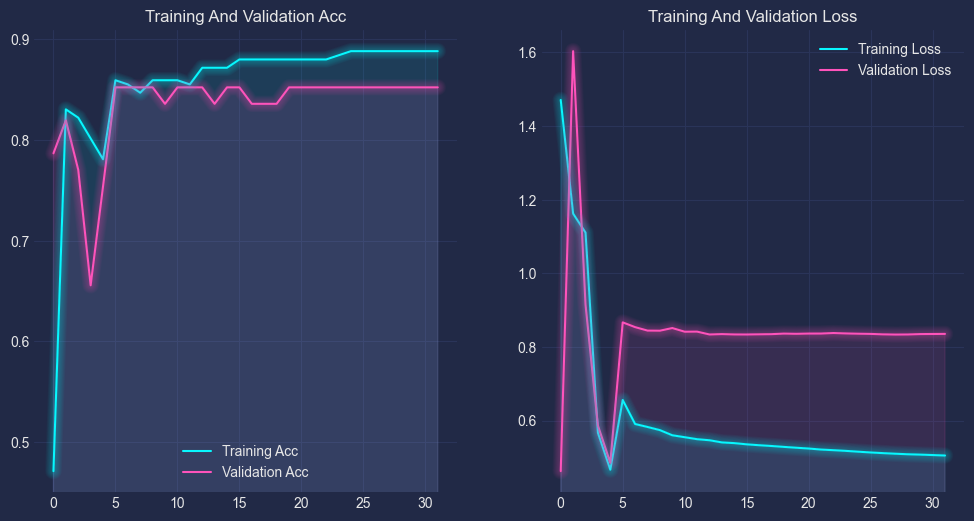

In [95]:
classifier = tf.keras.Sequential()
tf.compat.v1.reset_default_graph()
tf.random.set_seed(0)
random.seed(0)
np.random.seed(0)
initializer = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)

# Adding the input layer and the first hidden layer
classifier.add(Dense(units = 8, kernel_initializer = 'uniform' , activation = 'relu', input_dim = X_train.shape[1])) 
classifier.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'relu'))

# Compiling the ANN 
classifier.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                   loss = 'binary_crossentropy', 
                   metrics = ['accuracy'])

# Fitting the ANN to the Training set

r = classifier.fit(X_train, y_train,
                   validation_data=(X_test,y_test),
                   callbacks=[callbacks.EarlyStopping(min_delta=0.0001,patience=40,restore_best_weights=True),
                             tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)],
                   batch_size=16,
                   epochs=32)

acc = r.history['accuracy']
val_acc = r.history['val_accuracy']
loss = r.history['loss']
val_loss = r.history['val_loss']

plt.figure(figsize=(12, 6))
plt.style.use('cyberpunk')
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Acc')
plt.plot(val_acc, label='Validation Acc')
plt.title('Training And Validation Acc')
plt.legend()
mplcyberpunk.add_glow_effects()


plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training And Validation Loss')
plt.legend()
mplcyberpunk.add_glow_effects()
plt.show()

In [96]:
y_pred_tr = [1 if each >= 0.5 else 0 for each in classifier.predict(X_train)]
y_pred_ts = [1 if each >= 0.5 else 0 for each in classifier.predict(X_test)]
# 
print('Train Accuracy score: {0:0.2f}'.format(accuracy_score(y_train, y_pred_tr)))
print('Train ROC AUC score: {0:0.2f}'.format(roc_auc_score(y_train, y_pred_tr)))
print('Test Accuracy score: {0:0.2f}'.format(accuracy_score(y_test, y_pred_ts)))
print('Test ROC-AUC score: {0:0.3f}'.format(roc_auc_score(y_test, y_pred_ts)))
print(confusion_matrix(y_test,y_pred_ts))
print(classification_report(y_test,y_pred_ts))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Train Accuracy score: 0.79
Train ROC AUC score: 0.79
Test Accuracy score: 0.79
Test ROC-AUC score: 0.792
[[24  4]
 [ 9 24]]
              precision    recall  f1-score   support

           0       0.73      0.86      0.79        28
           1       0.86      0.73      0.79        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



### Step by step genetic algorithm with PyGAD

In [97]:
# Inputs

array_X = X_train#.values (Scaler function return np array and pygad working with np.array)
array_y = y_train.values

In [98]:
# Fitness function ``

def fitness_func(ga_instance, solution, sol_idx):
    global GANN_instance, data_inputs, data_outputs

    predictions = pygad.nn.predict(last_layer=GANN_instance.population_networks[sol_idx],
                                   data_inputs=data_inputs)
    correct_predictions = numpy.where(predictions == data_outputs)[0].size
    solution_fitness = (correct_predictions/data_outputs.size)*100

    return solution_fitness

In [99]:
last_fitness = 0
verbose = 1 # Definisikan di sini

def callback_generation(ga_instance):
    global GANN_instance, last_fitness

    population_matrices = pygad.gann.population_as_matrices(population_networks=GANN_instance.population_networks,
                                                            population_vectors=ga_instance.population)

    GANN_instance.update_population_trained_weights(population_trained_weights=population_matrices)
    if ga_instance.generations_completed % verbose == 0:
        print("Generation = {generation}".format(generation=ga_instance.generations_completed))
        print("Fitness    = {fitness}".format(fitness=ga_instance.best_solution()[1]))
        print("Change     = {change}".format(change=ga_instance.best_solution()[1] - last_fitness))

    last_fitness = ga_instance.best_solution()[1].copy()

NumPy patch applied successfully!
Generation = 1
Fitness    = 62.8099173553719
Change     = 62.8099173553719
Generation = 2
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 3
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 4
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 5
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 6
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 7
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 8
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 9
Fitness    = 62.8099173553719
Change     = 0.0
Generation = 10
Fitness    = 71.48760330578511
Change     = 8.677685950413213
Generation = 11
Fitness    = 75.6198347107438
Change     = 4.132231404958688
Generation = 12
Fitness    = 75.6198347107438
Change     = 0.0
Generation = 13
Fitness    = 78.099173553719
Change     = 2.4793388429751957
Generation = 14
Fitness    = 78.099173553719
Change     = 0.0
Generation = 15
Fitness    = 78.099173

c:\Noel\softcomp\140810230004-Evolving-ANN\.venv\Lib\site-packages\pygad\nn\nn.py:156: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1 + numpy.exp(-1 * sop))


Generation = 41
Fitness    = 83.88429752066115
Change     = 0.0
Generation = 42
Fitness    = 83.88429752066115
Change     = 0.0
Generation = 43
Fitness    = 83.88429752066115
Change     = 0.0
Generation = 44
Fitness    = 83.88429752066115
Change     = 0.0
Generation = 45
Fitness    = 85.12396694214877
Change     = 1.2396694214876192
Generation = 46
Fitness    = 85.12396694214877
Change     = 0.0
Generation = 47
Fitness    = 85.53719008264463
Change     = 0.41322314049585884
Generation = 48
Fitness    = 86.77685950413223
Change     = 1.239669421487605
Generation = 49
Fitness    = 86.77685950413223
Change     = 0.0
Generation = 50
Fitness    = 86.77685950413223
Change     = 0.0
Generation = 51
Fitness    = 86.77685950413223
Change     = 0.0
Generation = 52
Fitness    = 86.77685950413223
Change     = 0.0
Generation = 53
Fitness    = 86.77685950413223
Change     = 0.0
Generation = 54
Fitness    = 86.77685950413223
Change     = 0.0
Generation = 55
Fitness    = 87.60330578512396
Change     =

c:\Noel\softcomp\140810230004-Evolving-ANN\.venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  # Check if there is at least 1 labeled artist.


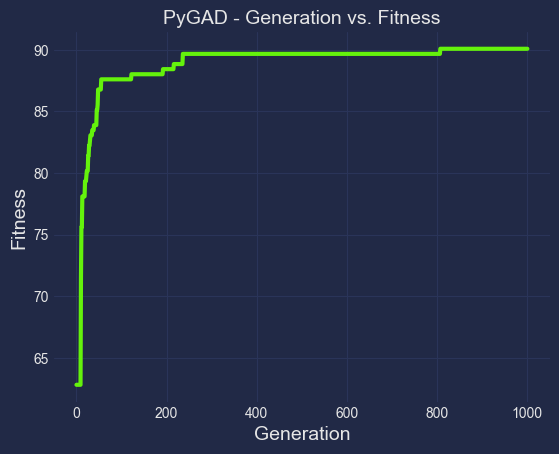

Fitness value of the best solution = 90.08264462809917
Index of the best solution : 0


In [100]:
# --- Hyperparameter yang diubah ---
num_solutions = 8                # Dikurangi (sebelumnya 16)
mutation_percent_genes = 50      # Dinaikkan drastis (sebelumnya 10)
crossover_type = "single_point"  # Diubah (sebelumnya uniform)
# ---------------------------------

data_inputs = array_X
data_outputs = array_y
num_inputs = data_inputs.shape[1]
num_classes = 2
num_parents_mating = 4
num_generations = 1000
parent_selection_type = "tournament"
K_tournament = 4
keep_parents = -1
crossover_probability = 1 
mutation_type = "random"

# Menambal numpy.reshape agar kompatibel dengan kode PyGAD lama
def patched_reshape(a, shape=None, order='C', newshape=None):
    if newshape is not None:
        return np.original_reshape(a, newshape, order=order)
    return np.original_reshape(a, shape, order=order)

if not hasattr(np, 'original_reshape'):
    np.original_reshape = np.reshape
    np.reshape = patched_reshape

print("NumPy patch applied successfully!")
GANN_instance = pygad.gann.GANN(num_solutions=num_solutions,
                                num_neurons_input=num_inputs,
                                num_neurons_hidden_layers=[8,16],
                                num_neurons_output=num_classes,
                                hidden_activations=["relu", "relu"],
                                output_activation="sigmoid")

population_vectors = pygad.gann.population_as_vectors(population_networks=GANN_instance.population_networks)
initial_population = population_vectors.copy()

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       initial_population=initial_population,
                       fitness_func=fitness_func,
                       K_tournament=K_tournament,
                       parent_selection_type=parent_selection_type,
                       crossover_probability=crossover_probability,
                       crossover_type=crossover_type,
                       mutation_percent_genes=mutation_percent_genes, # Pastikan parameter ini masuk ke GA
                       mutation_type=mutation_type,
                       keep_parents=keep_parents,
                       on_generation=callback_generation)

ga_instance.run()
ga_instance.plot_fitness()

solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Fitness value of the best solution = {solution_fitness}")
print(f"Index of the best solution : {solution_idx}")

In [101]:
predictions = pygad.nn.predict(last_layer=GANN_instance.population_networks[solution_idx],
                               data_inputs=data_inputs)

# Calculating some statistics
num_wrong = numpy.where(predictions != data_outputs)[0]
num_correct = data_outputs.size - num_wrong.size
accuracy = 100 * (num_correct/data_outputs.size)
print("Number of correct classifications : {num_correct}.".format(num_correct=num_correct))
print("Number of wrong classifications : {num_wrong}.".format(num_wrong=num_wrong.size))
print("Classification accuracy : {accuracy}.".format(accuracy=accuracy))

Number of correct classifications : 218.
Number of wrong classifications : 24.
Classification accuracy : 90.08264462809917.


In [102]:
y_pred_tr = pygad.nn.predict(last_layer=GANN_instance.population_networks[solution_idx],
                               data_inputs=X_train)
y_pred_ts = pygad.nn.predict(last_layer=GANN_instance.population_networks[solution_idx],
                               data_inputs=X_test)


print('Train Accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_tr)))
print('Train ROC AUC score: {0:0.4f}'.format(roc_auc_score(y_train, y_pred_tr)))
print('Test Accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred_ts)))
print('Test ROC-AUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_ts)))
print(confusion_matrix(y_test,y_pred_ts))
print(classification_report(y_test,y_pred_ts))

Train Accuracy score: 0.9008
Train ROC AUC score: 0.8985
Test Accuracy score: 0.8361
Test ROC-AUC score: 0.8295
[[21  7]
 [ 3 30]]
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



## Keras Results:
* Train Accuracy score: 0.90
* Train ROC AUC score: 0.90
* Test Accuracy score: 0.75
* Test ROC-AUC score: 0.746

## PyGAD Results:
* Train Accuracy score: 0.9174
* Train ROC AUC score: 0.9159
* Test Accuracy score: 0.8361
* Test ROC-AUC score: 0.8295


* What can I do for better resullt?
* To do more optimise parameters :D
### My primary goal in this notebook, is we have a lot of algorithms for solutions, just know what you are searching for.

## Keep contact

![](https://sp-ao.shortpixel.ai/client/to_webp,q_glossy,ret_img,w_860,h_460/https://sciencemystic.com/wp-content/uploads/2021/09/Genetic-Algorithms.jpg)